In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

sns.set()

# Métodos de ensamble
## Bagging y Random Forest
**Aprendizaje de Máquina - CEIA - FIUBA**

En la notebook anterior combinamos modelos **distintos** (logística, k-NN, SVC, árbol)
y vimos que la ganancia fue chica: los modelos no eran suficientemente diversos entre
sí, y un ensamble no puede inventar diversidad que no existe.

Acá cambiamos de estrategia. En lugar de esperar que los modelos sean diversos, vamos a
**fabricar la diversidad a propósito**: entrenamos muchas copias del *mismo* tipo de
modelo, pero cada una sobre datos distintos. Esa es la idea de:

- **Bagging** (*bootstrap aggregating*): cada modelo se entrena sobre un remuestreo
  aleatorio con reposición del conjunto de entrenamiento.
- **Random Forest**: además del remuestreo de datos, cada división del árbol considera
  sólo un subconjunto aleatorio de los atributos.

Usamos árboles como modelo base, y hay una razón para eso que vamos a ver enseguida.

## El dataset: Hitters

Volvemos al dataset **Hitters**: datos
de jugadores de béisbol de la liga estadounidense de 1986–87, donde queremos predecir el
salario de 1987 a partir de las estadísticas de la temporada anterior.

Mantenemos **exactamente el mismo preprocesamiento y el mismo split** que en esas
clases, para poder comparar contra todo lo que ya entrenamos.

In [2]:
# Cargamos el dataset y repetimos el preprocesamiento de las clases 3 y 4
df_hitters = pd.read_csv("datasets/Hitters.csv")

# Descartamos los jugadores sin dato de salario
df_hitters = df_hitters.dropna(subset="Salary")

# Modelamos el logaritmo del salario (ver EDA de la clase 3)
df_hitters["Salary_log"] = np.log(df_hitters["Salary"])

# Variables categóricas a dummies
df_hitters_dummies = pd.get_dummies(data=df_hitters,
                                    columns=['League', 'Division', 'NewLeague'],
                                    drop_first=True)

X_cols = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
          'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
          'Errors', 'League_N', 'Division_W', 'NewLeague_N']

X = df_hitters_dummies.loc[:, X_cols]
y = df_hitters_dummies.loc[:, 'Salary_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras | Testeo: {X_test.shape[0]}")

Entrenamiento: 184 muestras | Testeo: 79


La métrica principal es el **MAE** sobre el
logaritmo del salario (menor es mejor). Armamos la función de evaluación de siempre.

In [3]:
def evaluar(nombre, modelo, cv=True):
    """Entrena, evalúa en test y (opcionalmente) estima el MAE por CV."""
    mae_cv = np.nan
    if cv:
        mae_cv = -cross_val_score(modelo, X_train, y_train, cv=5,
                                  scoring='neg_mean_absolute_error',
                                  n_jobs=-1).mean()

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    return {
        "modelo": nombre,
        "MAE (train)": mean_absolute_error(y_train, modelo.predict(X_train)),
        "MAE (CV)": mae_cv,
        "MAE (test)": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    }

---
## El problema: el árbol tiene mucha varianza

Antes de ensamblar nada, entendamos **por qué** los árboles son el modelo base ideal
para bagging.

Un árbol sin podar tiene **sesgo bajo pero varianza altísima**: se ajusta muy bien a los
datos que ve (MAE de entrenamiento = 0), pero es tremendamente sensible a *cuáles* son
esos datos. Cambiar unas pocas muestras del entrenamiento puede cambiar la primera
división del árbol y, a partir de ahí, toda su estructura.

Comprobémoslo. Vamos a entrenar dos árboles sobre dos muestras distintas del mismo
entrenamiento y comparar sus predicciones.

In [4]:
rng = np.random.default_rng(42)
n = len(X_train)

# Dos remuestreos aleatorios distintos del mismo conjunto de entrenamiento
arboles, predicciones = [], []
for _ in range(2):
    idx = rng.choice(n, size=n, replace=True)
    arbol = DecisionTreeRegressor(random_state=42)
    arbol.fit(X_train.iloc[idx], y_train.iloc[idx])
    arboles.append(arbol)
    predicciones.append(arbol.predict(X_test))

print(f"MAE del árbol 1: {mean_absolute_error(y_test, predicciones[0]):.4f}")
print(f"MAE del árbol 2: {mean_absolute_error(y_test, predicciones[1]):.4f}")
print(f"Primera división del árbol 1: {X_cols[arboles[0].tree_.feature[0]]}"
      f" <= {arboles[0].tree_.threshold[0]:.1f}")
print(f"Primera división del árbol 2: {X_cols[arboles[1].tree_.feature[0]]}"
      f" <= {arboles[1].tree_.threshold[0]:.1f}")
print(f"\nDiferencia media entre las predicciones de ambos árboles: "
      f"{np.abs(predicciones[0] - predicciones[1]).mean():.4f}")

MAE del árbol 1: 0.4491
MAE del árbol 2: 0.5852
Primera división del árbol 1: CHits <= 419.0
Primera división del árbol 2: CRBI <= 131.0

Diferencia media entre las predicciones de ambos árboles: 0.4994


Los dos árboles fueron entrenados con datos del mismo origen y difieren entre sí
tanto como se diferencian del valor real. **Esa inestabilidad es varianza**, y es
precisamente lo que bagging ataca.

La idea es simple: si cada árbol se equivoca mucho pero **en direcciones distintas**,
promediar muchos árboles cancela buena parte de ese error. Es el mismo principio por el
que el promedio de muchas mediciones ruidosas es más preciso que una sola medición.

---
## El bootstrap

El *bootstrap* es el mecanismo que genera esa diversidad: de un conjunto de $n$
muestras, se sortean $n$ muestras **con reposición**. Algunas quedan repetidas y otras
no salen sorteadas nunca.

¿Cuántas quedan afuera? La probabilidad de que una muestra puntual *no* sea elegida en
un sorteo es $(1 - 1/n)$, y como hacemos $n$ sorteos:

$$P(\text{no salir nunca}) = \left(1 - \frac{1}{n}\right)^n
\xrightarrow[n \to \infty]{} \frac{1}{e} \approx 0.368$$

Es decir: cada árbol ve aproximadamente el **63.2%** de las muestras originales, y el
**36.8%** restante le queda "afuera". Verifiquémoslo.

In [5]:
idx = rng.choice(n, size=n, replace=True)
unicas = len(np.unique(idx))

print(f"Tamaño del entrenamiento: {n}")
print(f"Muestras distintas en el remuestreo: {unicas} ({unicas / n:.1%})")
print(f"Muestras que quedaron afuera: {n - unicas} ({1 - unicas / n:.1%})")
print(f"\nValor teórico: {1 - 1 / np.e:.1%} adentro, {1 / np.e:.1%} afuera")

Tamaño del entrenamiento: 184
Muestras distintas en el remuestreo: 115 (62.5%)
Muestras que quedaron afuera: 69 (37.5%)

Valor teórico: 63.2% adentro, 36.8% afuera


Ese 36.8% que queda afuera no es un desperdicio: son datos que ese árbol **no
vio**, así que sirven para evaluarlo gratis. Volvemos sobre esto en un rato (*out-of-bag*).

---
## Bagging: promediar muchos árboles

Ahora hagamos el experimento completo: entrenamos 200 árboles sin podar, cada uno sobre
su propio remuestreo bootstrap, y comparamos el error de **cada árbol individual**
contra el error del **promedio de todos**.

In [6]:
n_arboles = 200
preds_individuales = np.zeros((n_arboles, len(X_test)))

for i in range(n_arboles):
    idx_b = rng.choice(n, size=n, replace=True)
    arbol = DecisionTreeRegressor(random_state=i)
    arbol.fit(X_train.iloc[idx_b], y_train.iloc[idx_b])
    preds_individuales[i] = arbol.predict(X_test)

# MAE de cada árbol por separado
mae_individuales = np.array([mean_absolute_error(y_test, p)
                             for p in preds_individuales])

# MAE del promedio acumulado: 1 árbol, 2 árboles, ..., 200 árboles
mae_promedio = np.array([
    mean_absolute_error(y_test, preds_individuales[:k].mean(axis=0))
    for k in range(1, n_arboles + 1)
])

print(f"MAE promedio de un árbol individual: {mae_individuales.mean():.4f} "
      f"(desvío {mae_individuales.std():.4f})")
print(f"MAE del promedio de los {n_arboles} árboles: {mae_promedio[-1]:.4f}")

MAE promedio de un árbol individual: 0.4679 (desvío 0.0358)
MAE del promedio de los 200 árboles: 0.3519


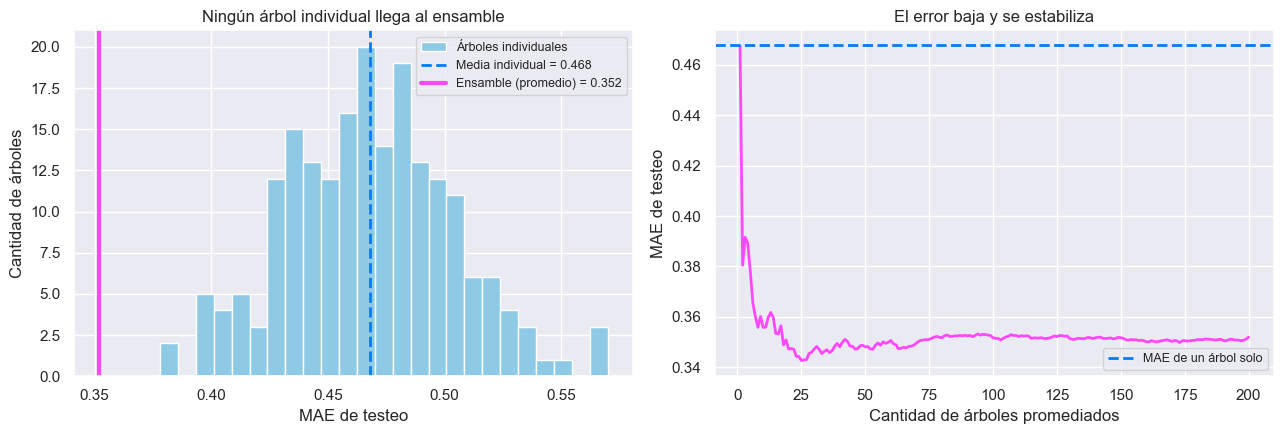

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: distribución del error de los árboles individuales vs el ensamble
axes[0].hist(mae_individuales, bins=25, color="#8ecae6", edgecolor="white",
             label="Árboles individuales")
axes[0].axvline(mae_individuales.mean(), color="#007aff", linestyle="--", lw=2,
                label=f"Media individual = {mae_individuales.mean():.3f}")
axes[0].axvline(mae_promedio[-1], color="#ff48fd", lw=3,
                label=f"Ensamble (promedio) = {mae_promedio[-1]:.3f}")
axes[0].set_xlabel("MAE de testeo")
axes[0].set_ylabel("Cantidad de árboles")
axes[0].set_title("Ningún árbol individual llega al ensamble")
axes[0].legend(fontsize=9)

# Derecha: cómo baja el error al agregar árboles
axes[1].plot(range(1, n_arboles + 1), mae_promedio, color="#ff48fd", lw=2)
axes[1].axhline(mae_individuales.mean(), color="#007aff", linestyle="--", lw=2,
                label="MAE de un árbol solo")
axes[1].set_xlabel("Cantidad de árboles promediados")
axes[1].set_ylabel("MAE de testeo")
axes[1].set_title("El error baja y se estabiliza")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Estos dos gráficos son el corazón de bagging:

- **A la izquierda:** el ensamble (línea rosa) queda **fuera de la distribución** de los
  árboles individuales. No es que el promedio sea "un árbol promedio": es mejor que
  *todos* los árboles que lo componen.
- **A la derecha:** el error cae rápido en los primeros árboles y después se estabiliza.
  Es una propiedad muy cómoda de bagging: **agregar más árboles nunca sobreajusta**,
  sólo deja de mejorar. El único costo de pasarse es tiempo de cómputo.

También podemos ver la reducción de varianza *punto a punto*. Tomemos unos pocos
jugadores del conjunto de testeo y miremos cuánto se dispersan las predicciones de los
200 árboles para cada uno.

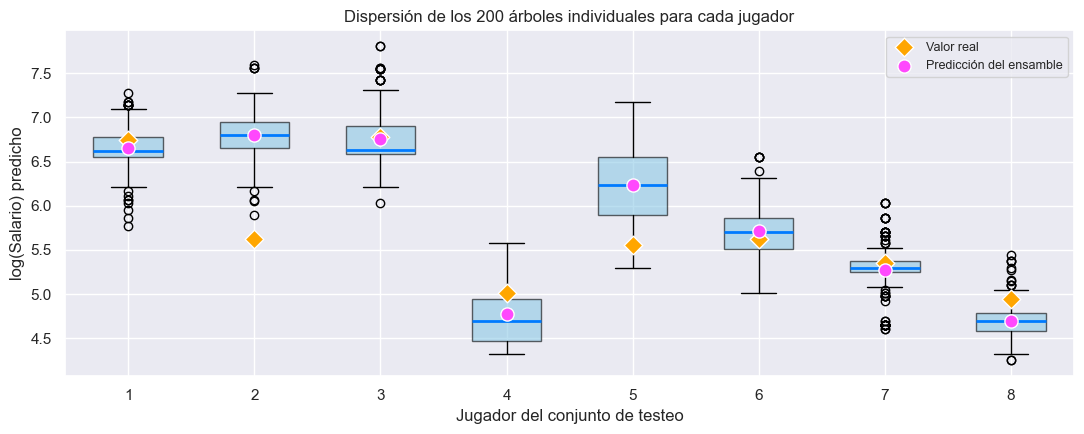

In [8]:
muestras = np.arange(8)
datos = [preds_individuales[:, i] for i in muestras]

fig, ax = plt.subplots(figsize=(11, 4.5))
bp = ax.boxplot(datos, patch_artist=True, widths=0.55,
                medianprops={"color": "#007aff", "linewidth": 2})
for caja in bp['boxes']:
    caja.set(facecolor="#8ecae6", alpha=0.6)

ax.scatter(np.arange(1, len(muestras) + 1), y_test.iloc[muestras], color="#ffa600",
           s=90, zorder=3, label="Valor real", marker="D", edgecolor="white")
ax.scatter(np.arange(1, len(muestras) + 1),
           preds_individuales[:, muestras].mean(axis=0), color="#ff48fd", s=90,
           zorder=3, label="Predicción del ensamble", marker="o",
           edgecolor="white")

ax.set_xlabel("Jugador del conjunto de testeo")
ax.set_ylabel("log(Salario) predicho")
ax.set_title("Dispersión de los 200 árboles individuales para cada jugador")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Cada caja muestra lo mucho que discrepan los 200 árboles sobre el **mismo**
jugador. El punto rosa —el promedio— cae sistemáticamente mucho más cerca del valor real
(rombo naranja) que el árbol típico.

### La clase `BaggingRegressor`

Todo lo anterior lo hicimos a mano para ver el mecanismo. Scikit-Learn lo tiene
implementado en
[`BaggingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html).

In [9]:
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                           n_estimators=200, random_state=42, n_jobs=-1)

# Árbol podado de la clase 4, como referencia
arbol_c4 = DecisionTreeRegressor(random_state=42, ccp_alpha=0.005)

metricas = [
    evaluar("Árbol podado", arbol_c4),
    evaluar("Bagging (200 árboles)", bagging),
]
pd.DataFrame(metricas).set_index("modelo").round(4)

,MAE (train),MAE (CV),MAE (test),RMSE,MAPE,R2
modelo,,,,,,
Árbol podado,0.2211,0.3643,0.4644,0.6653,0.0796,0.4321
Bagging (200 árboles),0.1051,0.2839,0.3487,0.5349,0.0604,0.6329


El MAE de testeo baja de **0.46 a 0.35**: una mejora del 25% sobre el árbol
podado previamente en clases anteriores, sin tocar un solo hiper-parámetro.

Fijate también en la columna **MAE (train)**: el bagging tiene un error de entrenamiento
muy bajo (≈ 0.10). Con un modelo común eso sería una alarma de sobreajuste, pero acá no
lo es tanto: cada árbol vio sólo el 63% de los datos, así que el error de entrenamiento
del ensamble ni siquiera es un error "en datos vistos" en el sentido habitual. Para
saber si sobreajusta hay que mirar la brecha con el MAE de CV o de testeo.

---
## Out-of-bag: validación gratis

Acá aprovechamos ese 36.8% de muestras que cada árbol no vio. Para cada muestra del
entrenamiento podemos predecir usando **solamente los árboles que no la vieron durante
su entrenamiento**. Eso da una estimación honesta del error de generalización, llamada
**out-of-bag (OOB)**, sin necesidad de separar un conjunto de validación ni de correr
validación cruzada.

Es una ventaja concreta de bagging: la validación viene incluida en el algoritmo. Se
activa con `oob_score=True`.

In [10]:
bagging_oob = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                               n_estimators=200, oob_score=True,
                               random_state=42, n_jobs=-1)
bagging_oob.fit(X_train, y_train)

# El OOB score de sklearn es el R2 sobre las predicciones out-of-bag
mae_oob = mean_absolute_error(y_train, bagging_oob.oob_prediction_)
mae_cv = -cross_val_score(bagging, X_train, y_train, cv=5,
                          scoring='neg_mean_absolute_error', n_jobs=-1).mean()

print(f"R2  out-of-bag           : {bagging_oob.oob_score_:.4f}")
print(f"MAE out-of-bag           : {mae_oob:.4f}")
print(f"MAE por validación cruzada: {mae_cv:.4f}")
print(f"MAE de testeo             : "
      f"{mean_absolute_error(y_test, bagging_oob.predict(X_test)):.4f}")

R2  out-of-bag           : 0.7747
MAE out-of-bag           : 0.2841
MAE por validación cruzada: 0.2839
MAE de testeo             : 0.3487


Las tres estimaciones son muy parecidas. La diferencia práctica es el costo: la
validación cruzada de 5 folds entrena **5 ensambles completos** (1000 árboles), mientras
que el OOB sale como subproducto de entrenar **uno solo** (200 árboles). En datasets
grandes esa diferencia es enorme.

---
## Random Forest: agregar diversidad en los atributos

Bagging tiene un límite. Si hay un atributo muy dominante —y en Hitters lo hay: las
variables de carrera como `CHits` o `CRuns`—, **todos los árboles van a elegirlo para su
primera división**. Los árboles terminan pareciéndose entre sí, sus errores se
correlacionan, y el promedio deja de compensar tanto.

Es exactamente el mismo problema que tuvimos en la notebook 1 con la logística y el SVC,
pero ahora dentro de un ensamble homogéneo.

**Random Forest** lo resuelve con una idea simple: en cada división, el árbol sólo puede
elegir entre un subconjunto aleatorio de `max_features` atributos. A veces el atributo
dominante no está disponible y el árbol se ve forzado a usar otro, lo que produce
árboles estructuralmente distintos. Se sacrifica algo de calidad individual a cambio de
**decorrelacionar** el ensamble.

Verifiquemos primero que los árboles del bagging efectivamente se parecen demasiado,
mirando qué atributo usan en la primera división.

In [11]:
primer_atributo = pd.Series(
    [X_cols[est.tree_.feature[0]] for est in bagging_oob.estimators_]
).value_counts()

print("Atributo elegido en la PRIMERA división por los 200 árboles del bagging:")
print(primer_atributo)

Atributo elegido en la PRIMERA división por los 200 árboles del bagging:
CRuns     93
CAtBat    55
CHits     39
CRBI      10
CWalks     3
Name: count, dtype: int64


Los 200 árboles se reparten entre apenas 5 atributos, y todos son variables de
carrera. Comparemos contra un Random Forest.

> ⚠️ **Una trampa importante.** El valor por defecto de `max_features` en
> `RandomForestRegressor` es **`1.0`**, es decir, *todos* los atributos. Dicho de otro
> modo: **un Random Forest de regresión con los parámetros por defecto es exactamente un
> bagging de árboles.** (En `RandomForestClassifier` el defecto sí es `'sqrt'`, así que
> ahí no pasa lo mismo.) Comprobémoslo.

In [12]:
rf_default = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)

primer_atributo_rf = pd.Series(
    [X_cols[est.tree_.feature[0]] for est in rf_default.estimators_]
).value_counts()

print(f"max_features por defecto: {rf_default.max_features}\n")
print("Primera división de los 200 árboles del Random Forest POR DEFECTO:")
print(primer_atributo_rf)
print(f"\n¿Idéntico al bagging? {primer_atributo_rf.equals(primer_atributo)}")

max_features por defecto: 1.0

Primera división de los 200 árboles del Random Forest POR DEFECTO:
CRuns     93
CAtBat    55
CHits     39
CRBI      10
CWalks     3
Name: count, dtype: int64

¿Idéntico al bagging? True


Efectivamente: **exactamente la misma distribución**. Si uno se queda con los
valores por defecto, no está haciendo Random Forest, está haciendo bagging.

Ahora sí, forcemos la aleatoriedad de atributos y veamos qué cambia.

In [13]:
rf_random = RandomForestRegressor(n_estimators=200, max_features=0.33,
                                  random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)

primer_atributo_rf33 = pd.Series(
    [X_cols[est.tree_.feature[0]] for est in rf_random.estimators_]
).value_counts()

print("Primera división de los 200 árboles con max_features=0.33:")
print(primer_atributo_rf33)

Primera división de los 200 árboles con max_features=0.33:
CHits     44
CAtBat    43
CRuns     37
CWalks    26
CRBI      26
CHmRun     8
Years      8
RBI        4
Hits       3
Walks      1
Name: count, dtype: int64


Ahora los árboles arrancan por **muchos** atributos distintos, incluidos varios
que en el bagging no aparecían nunca. Eso es la decorrelación en acción.

Barramos `max_features` para ver cuánta aleatoriedad conviene.

In [14]:
fracciones = np.round(np.arange(0.1, 1.01, 0.05), 2)
mae_cv_mf, mae_test_mf = [], []

for frac in fracciones:
    modelo = RandomForestRegressor(n_estimators=200, max_features=frac,
                                   random_state=42, n_jobs=-1)
    mae_cv_mf.append(-cross_val_score(modelo, X_train, y_train, cv=5,
                                      scoring='neg_mean_absolute_error',
                                      n_jobs=-1).mean())
    modelo.fit(X_train, y_train)
    mae_test_mf.append(mean_absolute_error(y_test, modelo.predict(X_test)))

mejor_frac = fracciones[int(np.argmin(mae_cv_mf))]
print(f"max_features óptimo (por CV): {mejor_frac:.2f} "
      f"(~{int(np.ceil(mejor_frac * len(X_cols)))} de {len(X_cols)} atributos)")

max_features óptimo (por CV): 0.35 (~7 de 19 atributos)


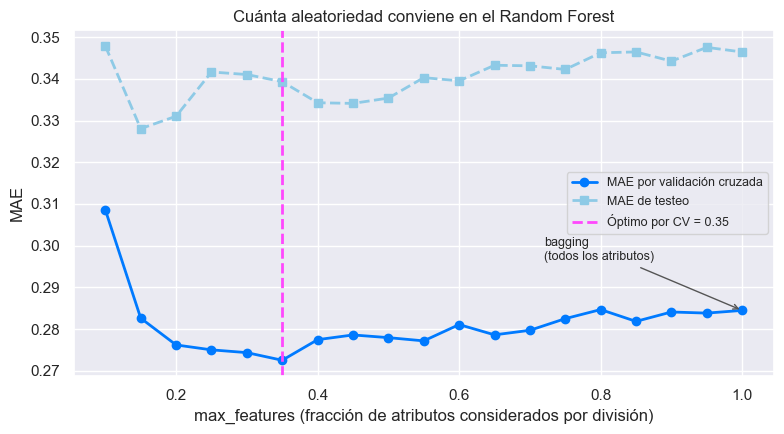

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(fracciones, mae_cv_mf, "o-", color="#007aff", lw=2,
        label="MAE por validación cruzada")
ax.plot(fracciones, mae_test_mf, "s--", color="#8ecae6", lw=2,
        label="MAE de testeo")
ax.axvline(mejor_frac, color="#ff48fd", linestyle="--", lw=2,
           label=f"Óptimo por CV = {mejor_frac:.2f}")
ax.annotate("bagging\n(todos los atributos)", xy=(1.0, mae_cv_mf[-1]),
            xytext=(0.72, mae_cv_mf[-1] + 0.012), fontsize=9,
            arrowprops={"arrowstyle": "->", "color": "#555555"})
ax.set_xlabel("max_features (fracción de atributos considerados por división)")
ax.set_ylabel("MAE")
ax.set_title("Cuánta aleatoriedad conviene en el Random Forest")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

La curva confirma la teoría:

- Con `max_features = 1.0` el Random Forest **es** bagging (es el defecto que vimos
  recién), y es donde el error es más alto.
- A medida que restringimos los atributos, los árboles se decorrelacionan y el error
  baja.
- Si restringimos demasiado, cada árbol se vuelve tan malo individualmente que el
  ensamble empeora.

El óptimo está en un valor intermedio. Entrenemos el Random Forest final con él.

In [16]:
rf_final = RandomForestRegressor(n_estimators=500, max_features=mejor_frac,
                                 oob_score=True, random_state=42, n_jobs=-1)

metricas.append(evaluar("Random Forest", rf_final))
pd.DataFrame(metricas).set_index("modelo").round(4)

,MAE (train),MAE (CV),MAE (test),RMSE,MAPE,R2
modelo,,,,,,
Árbol podado,0.2211,0.3643,0.4644,0.6653,0.0796,0.4321
Bagging (200 árboles),0.1051,0.2839,0.3487,0.5349,0.0604,0.6329
Random Forest,0.1024,0.2735,0.3387,0.5203,0.0585,0.6527


---
## Importancia de atributos

Una de las grandes ventajas de estos ensambles es que, a pesar de estar compuestos por
cientos de árboles, **siguen siendo interpretables** a nivel de qué variables importan.

Hay dos formas de medirlo, y conviene conocer las dos porque no siempre coinciden:

1. **Importancia por impureza** (`feature_importances_`): cuánto redujo la impureza cada
   atributo, sumado sobre todas las divisiones de todos los árboles. Es gratis (se
   calcula durante el entrenamiento), pero tiene un **sesgo conocido**: favorece a los
   atributos con muchos valores distintos (alta cardinalidad), porque ofrecen más puntos
   de corte posibles donde "encontrar" una mejora, aunque sea por azar. Además se
   calcula sobre los datos de entrenamiento.

2. **Importancia por permutación** (`permutation_importance`): se mezclan al azar los
   valores de un atributo y se mide cuánto empeora el modelo. Si empeora mucho, el
   atributo era importante. Es más cara de calcular, pero no tiene ese sesgo y —lo más
   importante— **se puede calcular sobre el conjunto de testeo**, midiendo la
   importancia para *generalizar* y no para memorizar.

Comparémoslas.

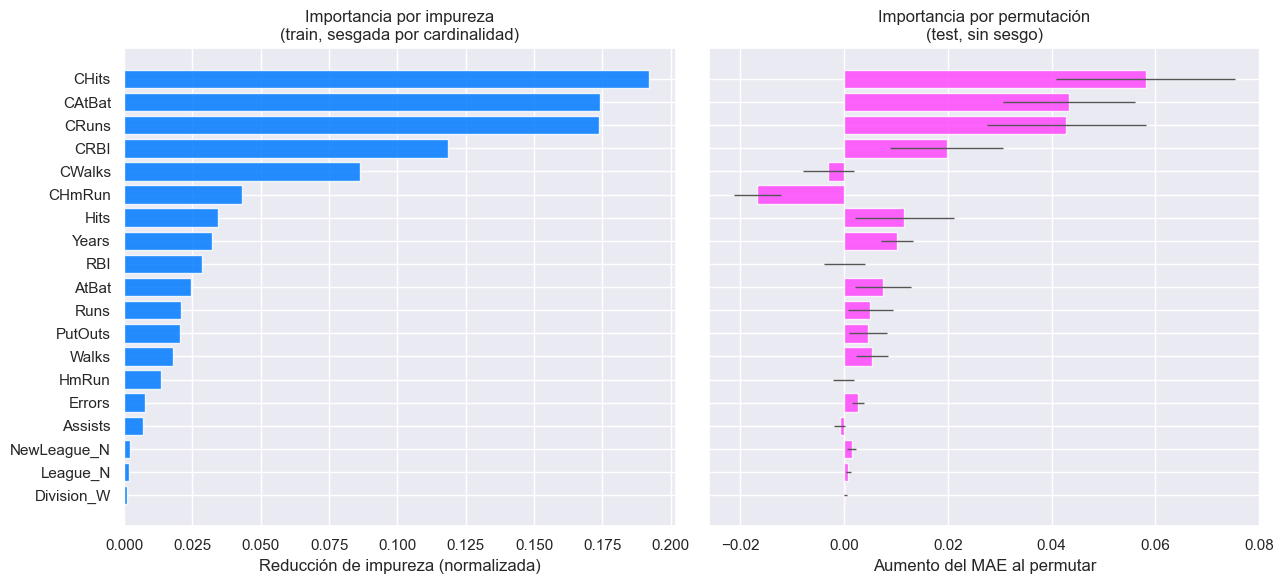

In [17]:
# 1) Importancia por impureza (viene con el modelo ya entrenado)
imp_impureza = pd.Series(rf_final.feature_importances_, index=X_cols)

# 2) Importancia por permutación, sobre el conjunto de TESTEO
perm = permutation_importance(rf_final, X_test, y_test, n_repeats=30,
                              random_state=42, n_jobs=-1,
                              scoring='neg_mean_absolute_error')
imp_perm = pd.Series(perm.importances_mean, index=X_cols)

orden = imp_impureza.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

axes[0].barh(orden, imp_impureza[orden], color="#007aff", alpha=0.85)
axes[0].set_xlabel("Reducción de impureza (normalizada)")
axes[0].set_title("Importancia por impureza\n(train, sesgada por cardinalidad)")

axes[1].barh(orden, imp_perm[orden], color="#ff48fd", alpha=0.85,
             xerr=perm.importances_std[[X_cols.index(a) for a in orden]],
             error_kw={"ecolor": "#555555", "lw": 1})
axes[1].set_xlabel("Aumento del MAE al permutar")
axes[1].set_title("Importancia por permutación\n(test, sin sesgo)")

plt.tight_layout()
plt.show()

In [18]:
comparacion = pd.DataFrame({
    "Impureza": imp_impureza,
    "Ranking impureza": imp_impureza.rank(ascending=False).astype(int),
    "Permutación": imp_perm,
    "Ranking permutación": imp_perm.rank(ascending=False).astype(int),
}).sort_values("Impureza", ascending=False)

comparacion.round(4)

,Impureza,Ranking impureza,Permutación,Ranking permutación
CHits,0.1921,1,0.0581,1
CAtBat,0.1740,2,0.0434,2
CRuns,0.1738,3,0.0428,3
CRBI,0.1186,4,0.0197,4
CWalks,0.0863,5,-0.0031,18
CHmRun,0.0430,6,-0.0167,19
Hits,0.0345,7,0.0116,5
Years,0.0323,8,0.0101,6
RBI,0.0284,9,-0.0000,15
AtBat,0.0246,10,0.0075,7


Los dos métodos coinciden en el **top-4**: las variables de carrera `CHits`,
`CAtBat`, `CRuns` y `CRBI` dominan la predicción del salario. Es tranquilizador y
coherente con el EDA y con el baseline por tramos de años.

Pero mirá lo que pasa un poco más abajo: **`CWalks` y `CHmRun` están 5º y 6º por
impureza, y caen a los últimos puestos (18º y 19º) por permutación**, ¡con importancia
negativa! Es decir, permutarlas al azar hace que el modelo funcione *ligeramente mejor*.

La explicación es la correlación. En Hitters las variables de carrera están
fuertemente correlacionadas entre sí (lo vimos en el EDA): `CWalks` aporta
casi la misma información que `CHits` y `CRuns`. Durante el entrenamiento, los árboles
la usan mucho —y por eso acumula reducción de impureza—, pero al permutarla el modelo
simplemente se apoya en sus hermanas correlacionadas y no pierde nada.

Esto deja dos advertencias prácticas:

- **La importancia por impureza sobrevalora a las variables redundantes**, porque cuenta
  cuántas veces se usaron sin preguntarse si eran reemplazables. Y arrastra además el
  sesgo de cardinalidad: las tres binarias (`League_N`, `Division_W`, `NewLeague_N`)
  quedan al fondo por impureza, pero la permutación las ubica por encima de `CWalks`.
- **La importancia por permutación reparte el crédito entre variables correlacionadas**,
  así que una importancia baja **no** significa "esta variable no sirve": puede
  significar "tengo otra que dice lo mismo". Para leerla bien conviene pensar en
  *grupos* de variables, no en variables sueltas.

Cuando los dos métodos discrepan, la permutación sobre test suele ser la más confiable,
porque mide lo que de verdad importa: cuánto se degrada el modelo con datos nuevos.

---
## Bonus: ¿qué le pasa a la función que aprende el modelo?

Para cerrar, una intuición visual. Ajustemos un modelo usando **un solo atributo**
(`CHits`, los hits acumulados en la carrera) para poder graficar la función aprendida, y
comparemos un árbol solo contra el bagging.

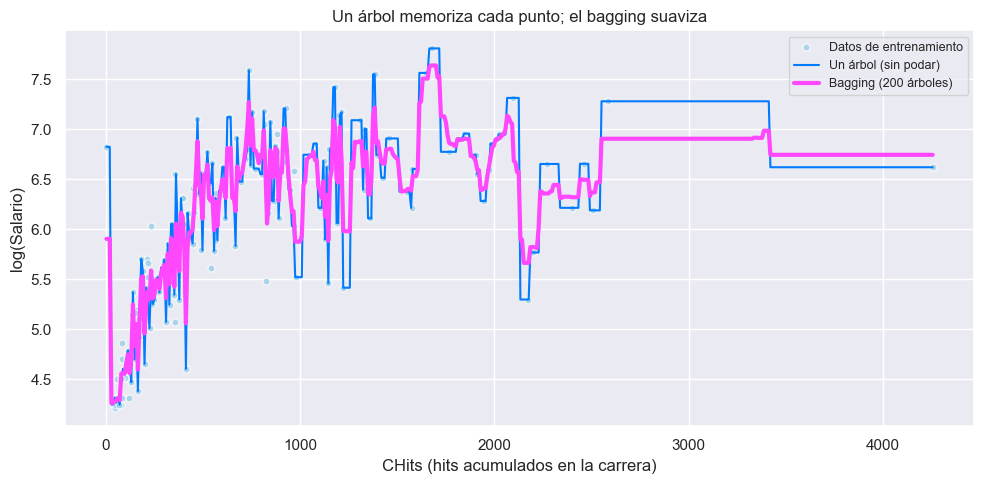

In [19]:
x_uni = X_train[["CHits"]]
grilla = np.linspace(X["CHits"].min(), X["CHits"].max(), 500).reshape(-1, 1)
grilla_df = pd.DataFrame(grilla, columns=["CHits"])  # type: ignore

arbol_uni = DecisionTreeRegressor(random_state=42).fit(x_uni, y_train)
bagging_uni = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                               n_estimators=200, random_state=42,
                               n_jobs=-1).fit(x_uni, y_train)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X_train["CHits"], y_train, s=25, color="#8ecae6", alpha=0.7,
           edgecolor="white", label="Datos de entrenamiento")
ax.plot(grilla, arbol_uni.predict(grilla_df), color="#007aff", lw=1.5,
        label="Un árbol (sin podar)")
ax.plot(grilla, bagging_uni.predict(grilla_df), color="#ff48fd", lw=3,
        label="Bagging (200 árboles)")

ax.set_xlabel("CHits (hits acumulados en la carrera)")
ax.set_ylabel("log(Salario)")
ax.set_title("Un árbol memoriza cada punto; el bagging suaviza")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Se ve perfectamente el efecto: el árbol solo (línea fina azul) produce una función
escalonada que pasa por **cada** punto de entrenamiento —está memorizando—, mientras que
el bagging (línea gruesa rosa) produce una curva mucho más suave que captura la
tendencia sin perseguir el ruido.

Y notemos algo importante: el bagging sigue siendo una **función escalonada** (es un
promedio de escalones), sólo que con escalones mucho más finos. Los ensambles de árboles
no dejan de ser árboles: no extrapolan fuera del rango de los datos, y por eso la curva
se aplana en los extremos.

---
## Comparativa final

Reunimos **todos** los modelos entrenados sobre Hitters a lo largo del curso, con el
mismo split (`test_size=0.3`, `random_state=42`), incluyendo la heurística de
referencia:

- **Baseline (tramos de años)** — heurística del EDA de la clase 3: predice el salario
  promedio del tramo de experiencia al que pertenece el jugador. Sin entrenamiento, es
  el piso contra el que hay que comparar.
- **Regresión Lineal (OLS)** y **Ridge** (`alpha=13.67`) — clase 3, notebook auxiliar de
  regresión lineal.
- **SVR (RBF)** (`C=10`, `gamma=0.1`) — el mejor SVR de la clase 3, que **venía siendo
  el campeón del curso** en este dataset.
- **Árbol de regresión podado** (`ccp_alpha=0.005`) — clase 4.
- **Bagging** y **Random Forest** — los ensambles de esta notebook.

In [20]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# --- Baseline heurístico: promedio de log(Salary) por tramo de años ---
bins = [0, 2, 4, 6, 9, 13, np.inf]
tramo_train = pd.cut(X_train["Years"], bins=bins)
tramo_test = pd.cut(X_test["Years"], bins=bins)
prom_por_tramo = y_train.groupby(tramo_train, observed=False).mean()
y_pred_base = tramo_test.map(prom_por_tramo).astype(float).values

fila_baseline = {
    "modelo": "Baseline (tramos de años)",
    "MAE (train)": mean_absolute_error(
        y_train, tramo_train.map(prom_por_tramo).astype(float).values),
    "MAE (CV)": np.nan,
    "MAE (test)": mean_absolute_error(y_test, y_pred_base),
    "RMSE": root_mean_squared_error(y_test, y_pred_base),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_base),
    "R2": r2_score(y_test, y_pred_base),
}

# --- Modelos de las clases 3 y 4 (necesitan escalado los lineales y el SVR) ---
ols = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=13.67))])
svr = Pipeline([('scaler', StandardScaler()),
                ('model', SVR(C=10, gamma=0.1, kernel='rbf'))])

df_final = pd.DataFrame([
    fila_baseline,
    evaluar("Regresión Lineal", ols),
    evaluar("Ridge", ridge),
    evaluar("SVR RBF", svr),
    evaluar("Árbol podado", arbol_c4),
    evaluar("Bagging", bagging),
    evaluar("Random Forest", rf_final),
]).set_index("modelo")

df_final.round(4)

,MAE (train),MAE (CV),MAE (test),RMSE,MAPE,R2
modelo,,,,,,
Baseline (tramos de años),0.4729,NaN,0.5068,0.7027,0.0869,0.3665
Regresión Lineal,0.4744,0.5380,0.5154,0.6779,0.0907,0.4103
Ridge,0.4839,0.5206,0.5118,0.6626,0.0904,0.4366
SVR RBF,0.0878,0.3771,0.3918,0.5702,0.0683,0.5828
Árbol podado,0.2211,0.3643,0.4644,0.6653,0.0796,0.4321
Bagging,0.1051,0.2839,0.3487,0.5349,0.0604,0.6329
Random Forest,0.1024,0.2735,0.3387,0.5203,0.0585,0.6527


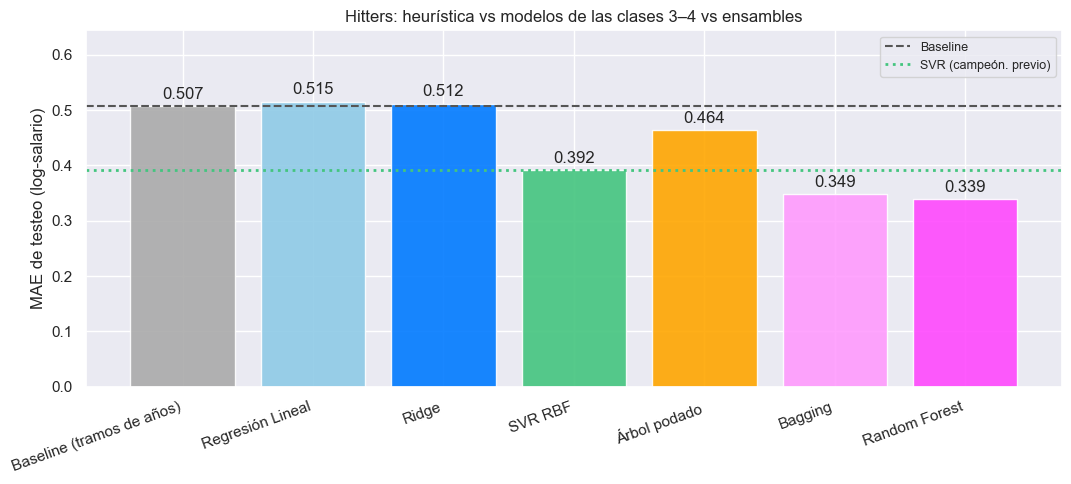

In [21]:
orden = ["Baseline (tramos de años)", "Regresión Lineal", "Ridge",
         "SVR RBF", "Árbol podado", "Bagging",
         "Random Forest"]
colores = ["#aaaaaa", "#8ecae6", "#007aff", "#44c57f", "#ffa600", "#ff9bfd",
           "#ff48fd"]

fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.bar(orden, df_final.loc[orden, "MAE (test)"], color=colores,
                alpha=0.9, edgecolor="white")
ax.bar_label(barras, fmt="%.3f", padding=3)
ax.axhline(df_final.loc["Baseline (tramos de años)", "MAE (test)"],
           color="#555555", linestyle="--", lw=1.5, label="Baseline")
ax.axhline(df_final.loc["SVR RBF", "MAE (test)"], color="#44c57f",
           linestyle=":", lw=2, label="SVR (campeón. previo)")
ax.set_ylabel("MAE de testeo (log-salario)")
ax.set_ylim(0, df_final["MAE (test)"].max() * 1.25)
ax.set_title("Hitters: heurística vs modelos de las clases 3–4 vs ensambles")
plt.xticks(rotation=20, ha="right")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Observaciones

- **Los ensambles ganan, y por mucho.** El Random Forest baja el MAE a ≈ 0.34 y el
  bagging a ≈ 0.35, contra ≈ 0.46 del árbol podado. Es una mejora del
  **~27%** sobre el mejor árbol individual, y a diferencia de lo que pasaba con Pima en
  la notebook 1, acá el margen es lo bastante grande como para no ser ruido.
- **Y le ganan al SVR**, que venía siendo el campeón indiscutido de este dataset (MAE ≈ 0.39).
- **Random Forest ≥ Bagging**, como esperábamos: la decorrelación por `max_features`
  aporta una mejora chica pero consistente, y la curva en U nos mostró exactamente
  cuánta aleatoriedad convenía.
- **El baseline por tramos de años (MAE ≈ 0.51) sigue siendo respetable** y es el
  recordatorio de siempre: una sola regla derivada del EDA queda a la altura de una
  regresión lineal. Lo relevante es que los ensambles finalmente le sacan una diferencia
  clara (≈ 33% mejor), cosa que los modelos lineales no lograban.
- **Los modelos lineales (OLS y Ridge) apenas superan al baseline**, por la fuerte
  multicolinealidad entre las variables de carrera que ya habíamos identificado. Los
  ensambles de árboles, al partir el espacio de forma no lineal, exprimen mucha más
  señal de esos mismos datos.

### ¿Por qué acá funcionó y en Pima no?

Vale la pena comparar las dos notebooks:

| | Pima (notebook 1) | Hitters (notebook 2) |
|---|---|---|
| Tipo de ensamble | Heterogéneo (4 modelos distintos) | Homogéneo (200–500 árboles) |
| Origen de la diversidad | Esperada, no controlada | **Fabricada** (bootstrap + `max_features`) |
| Diversidad conseguida | Baja (logística y SVC al 0.91) | Alta y ajustable |
| Mejora sobre el mejor individual | ~0.01 (dentro del ruido) | ~0.05 MAE (27%) |

La diferencia no es solo el dataset: es que en bagging **controlamos** la diversidad en lugar
de esperar que aparezca. Ese es el motivo por el que los ensambles homogéneos son mucho
más usados en la práctica que los heterogéneos.

En la próxima notebook vemos la otra gran familia de ensambles homogéneos: en lugar de
entrenar los árboles **en paralelo** y promediarlos, el **boosting** los entrena **en
secuencia**, cada uno corrigiendo los errores del anterior.